# Task 3 — Ball Detection (YOLO vs RT-DETR)

Computer Vision project | M.EIC + M.IA | FEUP

**Goal of this notebook:** detect the *position* of the balls on the pool table
(bounding boxes, single class `Ball`). We train and **compare two detectors**:

| Model | Family | Why |
|-------|--------|-----|
| **YOLO11** (`yolo11s`) | CNN, one-stage, anchor-free | strong, fast, very well documented baseline |
| **RT-DETR** (`rtdetr-l`) | Transformer (DETR family) | end-to-end, no NMS, modern counterpart to YOLO; trains well on small datasets |

Both are trained from the **same dataset** (`data.yaml`, `nc=1`, `names=['Ball']`) and
evaluated on the **same `test` split** with the **same metrics**, so the comparison is fair.

> **Note (newer YOLO):** YOLO26 (Jan 2026) adds *Small-Target-Aware Label Assignment*,
> which can help with small objects like balls. To try it, just set
> `YOLO_MODEL = 'yolo26s.pt'` in the config cell (requires a recent `ultralytics`).

> **Acknowledgement (required by the brief):** detection uses the third-party
> [`ultralytics`](https://github.com/ultralytics/ultralytics) package (YOLO and RT-DETR).


## 0. Environment & imports

If `ultralytics` is not installed, uncomment the `pip install` line. The first
training run will also download the pretrained weights (`yolo11s.pt`, `rtdetr-l.pt`),
so an internet connection is needed the first time.

In [1]:
import os

# --- ROCm / AMD GPU compatibility (same overrides used in task2.py) ---
# Harmless on NVIDIA/CPU. Remove if you are on CUDA and they cause issues.
os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "10.3.0")
os.environ.setdefault("HSA_ENABLE_SDMA", "0")

# !pip install ultralytics  # uncomment on first run if needed

import json, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

# --- ROCm fix ---
# Several internal PyTorch ROCm entry points (device selection, manual_seed_all,
# lazy init...) call GPU-counting helpers that reference the optional `amdsmi`
# python bindings; when amdsmi is not installed this raises
# `NameError: name 'amdsmi' is not defined`. We replace the low-level helpers so
# every caller falls back to the device count that works fine on HIP/ROCm.
if getattr(torch.version, "hip", None):
    import torch.cuda as _tcuda
    def _safe_device_count():
        try:
            return torch._C._cuda_getDeviceCount()
        except Exception:
            return 0
    _tcuda._raw_device_count_amdsmi = _safe_device_count
    _tcuda._device_count_amdsmi = _safe_device_count
    _tcuda.device_count = _safe_device_count
    print("ROCm device_count patched ->", torch.cuda.device_count())

from ultralytics import YOLO, RTDETR

print("torch:", torch.__version__, "| CUDA/ROCm available:", torch.cuda.is_available())

ROCm device_count patched -> 1
torch: 2.4.1+rocm6.0 | CUDA/ROCm available: True


## 1. Configuration

Edit `DATASET_DIR` to point to the folder that contains `data.yaml` and the
`train/ valid/ test` sub-folders. Everything else can stay as is.

In [2]:
SEED      = 42
DATASET_DIR = "dataset"                 # folder containing data.yaml + train/valid/test
DATA_YAML   = os.path.join(DATASET_DIR, "data.yaml")

YOLO_MODEL  = "yolo11s.pt"              # try "yolo26s.pt" (small-object aware) or "yolo11m.pt"
RTDETR_MODEL = "rtdetr-l.pt"           # transformer detector (DETR family)

EPOCHS   = 100                          # upper bound; early stopping (patience) usually stops earlier
PATIENCE = 20                           # epochs without val improvement before stopping
IMG_SIZE = 640                          # shared by both models -> fair comparison + fits 8 GB VRAM
YOLO_BATCH   = 8                        # yolo11s is light; can go to 12-16 if VRAM allows
RTDETR_BATCH = 2                        # RT-DETR-l is heavy; batch 4 OOMs on 8 GB, so use 2
WORKERS  = 4                            # dataloader workers; lower = less RAM (no effect on accuracy)
DEVICE   = 0 if torch.cuda.is_available() else "cpu"

OUT_DIR  = "task3_runs"                 # all training runs + figures land here
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("device:", DEVICE)

device: 0


## 2. Resolve dataset paths

Ultralytics resolves the `train/val/test` entries in `data.yaml` relative to a
`path:` key (or to its global datasets dir), which is the single most common
source of *"dataset not found"* errors. To avoid that, we rewrite a copy of the
yaml with an **absolute `path:`** and explicit splits.

In [3]:
import yaml

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

cfg["path"]  = os.path.abspath(DATASET_DIR)
cfg["train"] = "train/images"
cfg["val"]   = "valid/images"
cfg["test"]  = "test/images"
cfg.setdefault("nc", 1)
cfg.setdefault("names", ["Ball"])

RESOLVED_YAML = os.path.abspath(os.path.join(OUT_DIR, "data_resolved.yaml"))
with open(RESOLVED_YAML, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Using:", RESOLVED_YAML)
print(json.dumps(cfg, indent=2))

Using: /home/rui/Documentos/VC/Proj_Task3/task3_runs/data_resolved.yaml
{
  "train": "train/images",
  "val": "valid/images",
  "test": "test/images",
  "nc": 1,
  "names": [
    "Ball"
  ],
  "path": "/home/rui/Documentos/VC/Proj_Task3/dataset"
}


## 3. Dataset exploration

Quick sanity check + material for the report: how many images per split, and how
many balls per image (each line in a YOLO label file = one box).

       n_images  total_balls  balls_per_img_mean
train    1560.0      14198.0            9.101282
valid     195.0       1701.0            8.723077
test      196.0       1725.0            8.801020


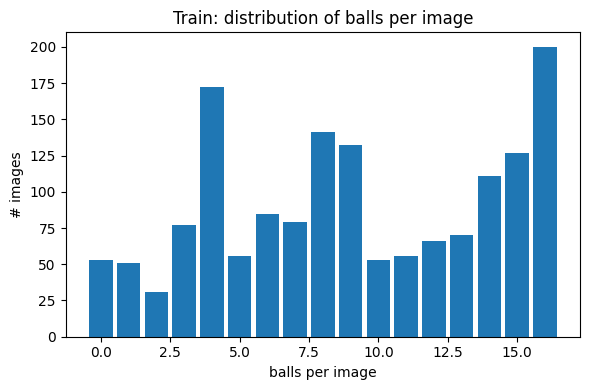

In [4]:
def split_dir(split):
    return os.path.join(DATASET_DIR, split, "images"), os.path.join(DATASET_DIR, split, "labels")

def count_boxes(label_path):
    if not os.path.exists(label_path):
        return 0
    with open(label_path) as f:
        return sum(1 for line in f if len(line.split()) >= 5)

stats = {}
for split in ["train", "valid", "test"]:
    img_dir, lbl_dir = split_dir(split)
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    counts = [count_boxes(os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + ".txt")) for p in imgs]
    stats[split] = {"n_images": len(imgs), "total_balls": int(np.sum(counts)),
                    "balls_per_img_mean": float(np.mean(counts)) if counts else 0.0, "counts": counts}

print(pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "counts"} for k, v in stats.items()}).T)

plt.figure(figsize=(6, 4))
train_counts = stats["train"]["counts"]
plt.hist(train_counts, bins=range(0, (max(train_counts) if train_counts else 1) + 2), align="left", rwidth=0.85)
plt.xlabel("balls per image"); plt.ylabel("# images"); plt.title("Train: distribution of balls per image")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ball_count_distribution.png"), dpi=120); plt.show()

Show a few **training images with their ground-truth boxes** (read directly
from the YOLO `.txt` labels and de-normalised to pixel coordinates).

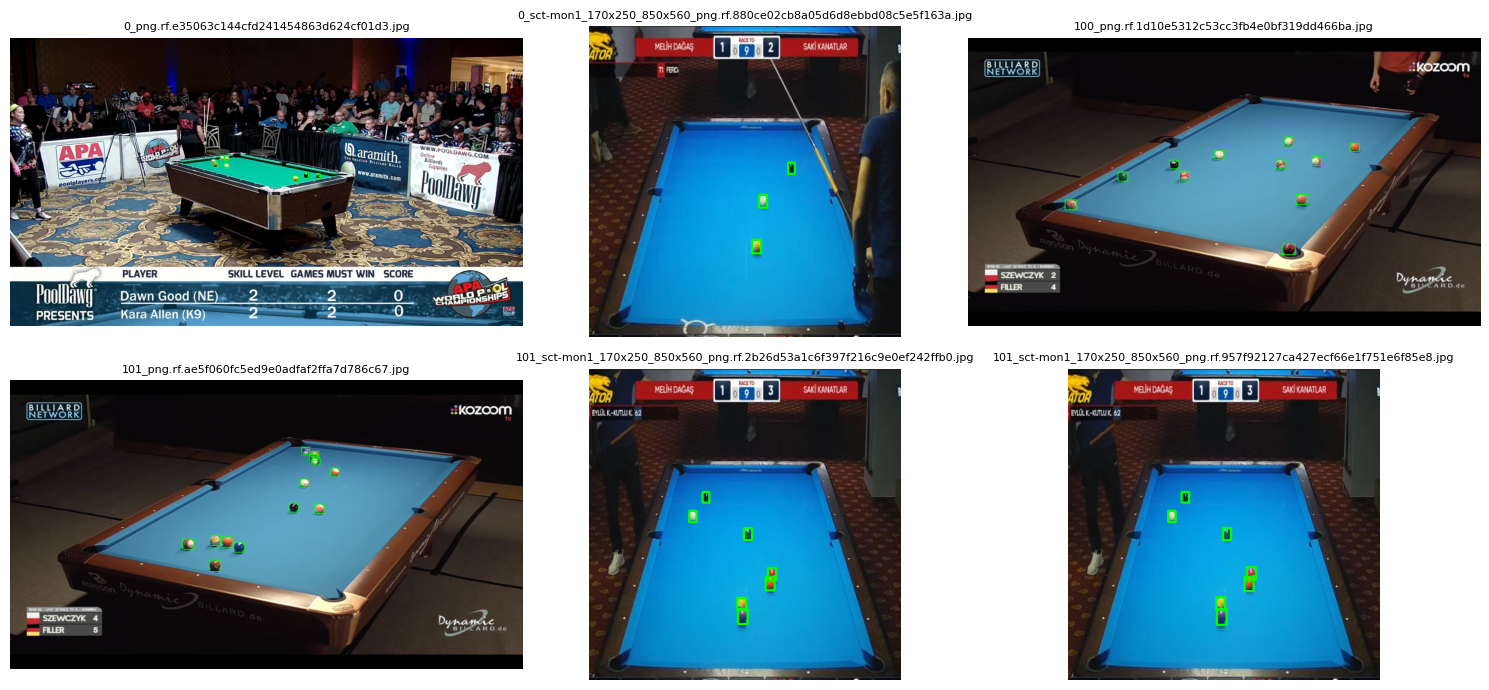

In [5]:
def draw_gt(img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            p = line.split()
            if len(p) < 5:
                continue
            cx, cy, bw, bh = map(float, p[1:5])
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return img

img_dir, lbl_dir = split_dir("train")
sample = sorted(glob.glob(os.path.join(img_dir, "*.*")))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, p in zip(axes.ravel(), sample):
    lbl = os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + ".txt")
    ax.imshow(draw_gt(p, lbl)); ax.set_title(os.path.basename(p), fontsize=8); ax.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "gt_samples.png"), dpi=120); plt.show()

## 4. Train Model 1 — YOLO11

Ultralytics handles augmentation, the train/val loop, early stopping (`patience`),
and saves curves + the best checkpoint automatically under `task3_runs/yolo/`.

In [6]:
yolo = YOLO(YOLO_MODEL)
yolo_train = yolo.train(
    data=RESOLVED_YAML, epochs=EPOCHS, patience=PATIENCE, imgsz=IMG_SIZE,
    batch=YOLO_BATCH, device=DEVICE, seed=SEED, project=OUT_DIR, name="yolo",
    workers=WORKERS, exist_ok=True, verbose=True,
)
YOLO_RUN = str(yolo.trainer.save_dir)   # actual dir ultralytics used (handles runs/detect/... nesting)
print("YOLO run dir:", YOLO_RUN)
print("Best weights:", os.path.join(YOLO_RUN, "weights", "best.pt"))

New https://pypi.org/project/ultralytics/8.4.68 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.4.1+rocm6.0 CUDA:0 (AMD Radeon RX 6600, 8176MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/rui/Documentos/VC/Proj_Task3/task3_runs/data_resolved.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0

### Evaluate YOLO11 on the test split

In [7]:
def extract_metrics(val_result, torch_module):
    b = val_result.box
    n_params = sum(p.numel() for p in torch_module.parameters())
    inf_ms = float(val_result.speed.get("inference", float("nan")))  # ms / image
    return {
        "mAP50-95": float(b.map), "mAP50": float(b.map50), "mAP75": float(b.map75),
        "precision": float(b.mp), "recall": float(b.mr),
        "params(M)": n_params / 1e6,
        "infer_ms": inf_ms, "img/s": (1000.0 / inf_ms) if inf_ms == inf_ms and inf_ms > 0 else float("nan"),
    }

yolo_best = YOLO(os.path.join(YOLO_RUN, "weights", "best.pt"))
yolo_test = yolo_best.val(data=RESOLVED_YAML, split="test", imgsz=IMG_SIZE, batch=YOLO_BATCH,
                          device=DEVICE, project=OUT_DIR, name="yolo_test", exist_ok=True)
YOLO_TEST_DIR = str(yolo_test.save_dir)
yolo_metrics = extract_metrics(yolo_test, yolo_best.model)
print(json.dumps(yolo_metrics, indent=2))

Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.4.1+rocm6.0 CUDA:0 (AMD Radeon RX 6600, 8176MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 116.2±62.2 MB/s, size: 56.7 KB)
val: Scanning /home/rui/Documentos/VC/Proj_Task3/dataset/test/labels... 196 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 2.2Kit/s 0.1s
val: New cache created: /home/rui/Documentos/VC/Proj_Task3/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.8it/s 6.7s<0.2s
                   all        196       1725      0.997      0.993      0.994      0.812
Speed: 1.0ms preprocess, 29.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /home/rui/Documentos/VC/Proj_Task3/runs/detect/task3_runs/yolo_test
{
  "mAP50-95": 0.8121882178559197,
  "mAP50": 0.994193076767418,
  "mAP75": 0.9716669741428599,
  "precision": 0.996

## 5. Train Model 2 — RT-DETR

Identical recipe and identical data, so the only thing that changes is the
architecture. RT-DETR is a transformer (object queries + set prediction) and
does **not** need NMS.

In [8]:
import gc
# Free the VRAM held by the YOLO *training* objects so RT-DETR starts clean.
# We keep `yolo_best` (a light inference model) for the qualitative section later.
for _v in ["yolo", "yolo_train"]:
    if _v in globals():
        del globals()[_v]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

rtdetr = RTDETR(RTDETR_MODEL)
rtdetr_train = rtdetr.train(
    data=RESOLVED_YAML, epochs=EPOCHS, patience=PATIENCE, imgsz=IMG_SIZE,
    batch=RTDETR_BATCH, device=DEVICE, seed=SEED, project=OUT_DIR, name="rtdetr",
    workers=WORKERS, exist_ok=True, verbose=True,
)
RTDETR_RUN = str(rtdetr.trainer.save_dir)
print("RT-DETR run dir:", RTDETR_RUN)
print("Best weights:", os.path.join(RTDETR_RUN, "weights", "best.pt"))

New https://pypi.org/project/ultralytics/8.4.68 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.4.1+rocm6.0 CUDA:0 (AMD Radeon RX 6600, 8176MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/rui/Documentos/VC/Proj_Task3/task3_runs/data_resolved.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=

/home/rui/Documentos/VC/myenv/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      5.85G     0.7165     0.3961     0.2223         66       1280: 100% ━━━━━━━━━━━━ 780/780 1.3it/s 9:510.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 5.5it/s 8.9s0.1s
                   all        195       1701      0.959      0.943      0.954      0.655

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/rui/Documentos/VC/myenv/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      5.92G     0.3728     0.3776    0.03861         56       1280: 100% ━━━━━━━━━━━━ 780/780 1.3it/s 9:450.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 8.3it/s 5.9s0.1s
                   all        195       1701      0.958      0.945      0.959      0.678

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

     73/100      6.05G     0.1698     0.2519    0.00791         73       1280: 100% ━━━━━━━━━━━━ 780/780 1.3it/s 9:450.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 8.0it/s 6.1s0.1s
                   all        195       1701      0.978      0.974      0.975      0.796

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/rui/Documentos/VC/myenv/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     74/100      5.92G     0.1652     0.2491   0.007579         56       1280: 100% ━━━━━━━━━━━━ 780/780 1.3it/s 9:500.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 7.9it/s 6.2s0.1s
                   all        195       1701      0.976      0.972      0.977      0.779

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/home/rui/Documentos/VC/myenv/lib/python3.10/site-packages/torch/autograd/graph.py:769: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:83.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     75/100      5.95G      0.183     0.2635   0.007441         48       1280: 100% ━━━━━━━━━━━━ 780/780 1.3it/s 9:490.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 8.0it/s 6.1s0.1s
                   all        195       1701      0.978      0.976       0.97      0.786
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 55, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

75 epochs completed in 12.337 hours.
Optimizer stripped from /home/rui/Documentos/VC/Proj_Task3/runs/detect/task3_runs/rtdetr/weights/last.pt, 66.2MB
Optimizer stripped from /home/rui/Documentos/VC/Proj_Task3/runs/detect/task3_runs/rtdetr/weights/best.pt, 66.2MB

Validating /home/rui/Documentos/VC/Proj_Task3/runs/detect/task3_runs/rtdetr/weights/best.pt...
Ultralytics 8.4.67 

### Evaluate RT-DETR on the test split

In [9]:
rtdetr_best = RTDETR(os.path.join(RTDETR_RUN, "weights", "best.pt"))
rtdetr_test = rtdetr_best.val(data=RESOLVED_YAML, split="test", imgsz=IMG_SIZE, batch=RTDETR_BATCH,
                              device=DEVICE, project=OUT_DIR, name="rtdetr_test", exist_ok=True)
RTDETR_TEST_DIR = str(rtdetr_test.save_dir)
rtdetr_metrics = extract_metrics(rtdetr_test, rtdetr_best.model)
print(json.dumps(rtdetr_metrics, indent=2))

Ultralytics 8.4.67 🚀 Python-3.10.12 torch-2.4.1+rocm6.0 CUDA:0 (AMD Radeon RX 6600, 8176MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 35.6±22.3 MB/s, size: 53.4 KB)
val: Scanning /home/rui/Documentos/VC/Proj_Task3/dataset/test/labels.cache... 196 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 41.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 98/98 8.3it/s 11.8s<0.2s
                   all        196       1725      0.995      0.986      0.995      0.832
Speed: 1.2ms preprocess, 55.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/rui/Documentos/VC/Proj_Task3/runs/detect/task3_runs/rtdetr_test
{
  "mAP50-95": 0.8317553693195949,
  "mAP50": 0.9946080818385765,
  "mAP75": 0.9820090843978492,
  "precision": 0.9948165121452807,
  "recall": 0.9855072463768116,
  "params(M)": 31.985795,
  "inf

## 6. Quantitative comparison

The brief asks for a *quantitative comparison with adequate metrics*. For object
detection the standard ones are **mAP@0.5** and **mAP@0.5:0.95** (IoU is the
matching criterion behind them), plus **precision** and **recall**. We also
report **model size (params)** and **inference latency** to expose the
accuracy-vs-cost trade-off (same idea as the Task 2 comparison).

In [10]:
comparison = pd.DataFrame({"YOLO11": yolo_metrics, "RT-DETR": rtdetr_metrics}).T
comparison = comparison[["mAP50-95", "mAP50", "mAP75", "precision", "recall", "params(M)", "infer_ms", "img/s"]]
comparison.to_csv(os.path.join(OUT_DIR, "detection_comparison.csv"))
comparison.round(4)

,mAP50-95,mAP50,mAP75,precision,recall,params(M),infer_ms,img/s
YOLO11,0.8122,0.9942,0.9717,0.9970,0.9930,9.4132,29.3481,34.0738
RT-DETR,0.8318,0.9946,0.9820,0.9948,0.9855,31.9858,55.2936,18.0853


Visual comparison: accuracy bars + an accuracy-vs-cost scatter
(closer to top-left = more accurate *and* faster).

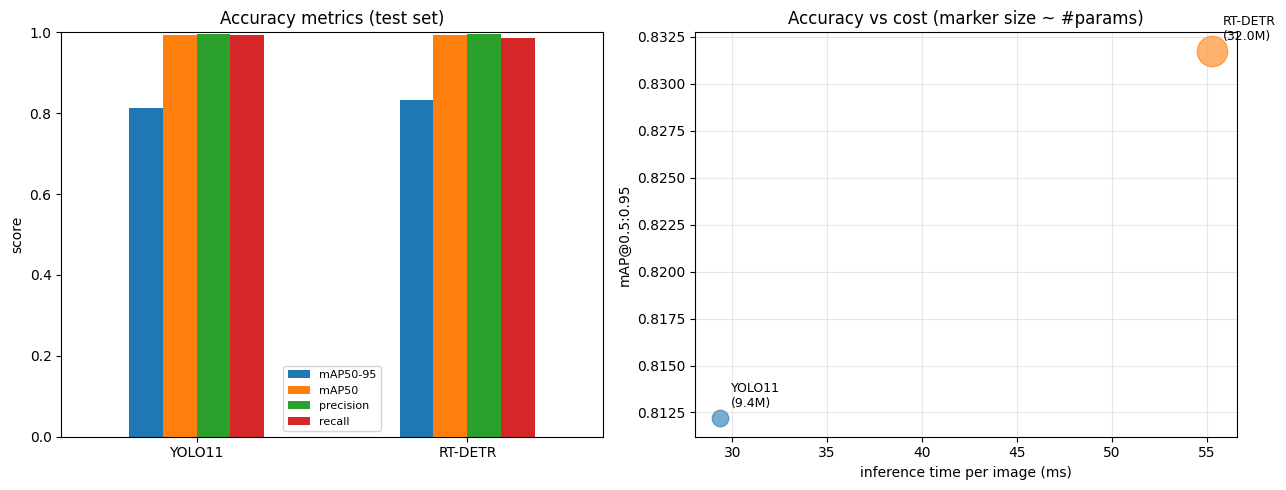

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

acc_cols = ["mAP50-95", "mAP50", "precision", "recall"]
comparison[acc_cols].plot.bar(ax=ax1, rot=0)
ax1.set_title("Accuracy metrics (test set)"); ax1.set_ylabel("score"); ax1.set_ylim(0, 1); ax1.legend(fontsize=8)

for name in comparison.index:
    ax2.scatter(comparison.loc[name, "infer_ms"], comparison.loc[name, "mAP50-95"],
                s=max(60, comparison.loc[name, "params(M)"] * 15), alpha=0.6)
    ax2.annotate(f"{name}\n({comparison.loc[name, 'params(M)']:.1f}M)",
                 (comparison.loc[name, "infer_ms"], comparison.loc[name, "mAP50-95"]),
                 textcoords="offset points", xytext=(8, 8), fontsize=9)
ax2.set_xlabel("inference time per image (ms)"); ax2.set_ylabel("mAP@0.5:0.95")
ax2.set_title("Accuracy vs cost (marker size ~ #params)"); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "detection_comparison.png"), dpi=120); plt.show()

Ultralytics saves rich diagnostic plots for every run. Below we pull the
**Precision-Recall curves** (from the test-set evaluation of each model).

YOLO11 - Precision-Recall curve:


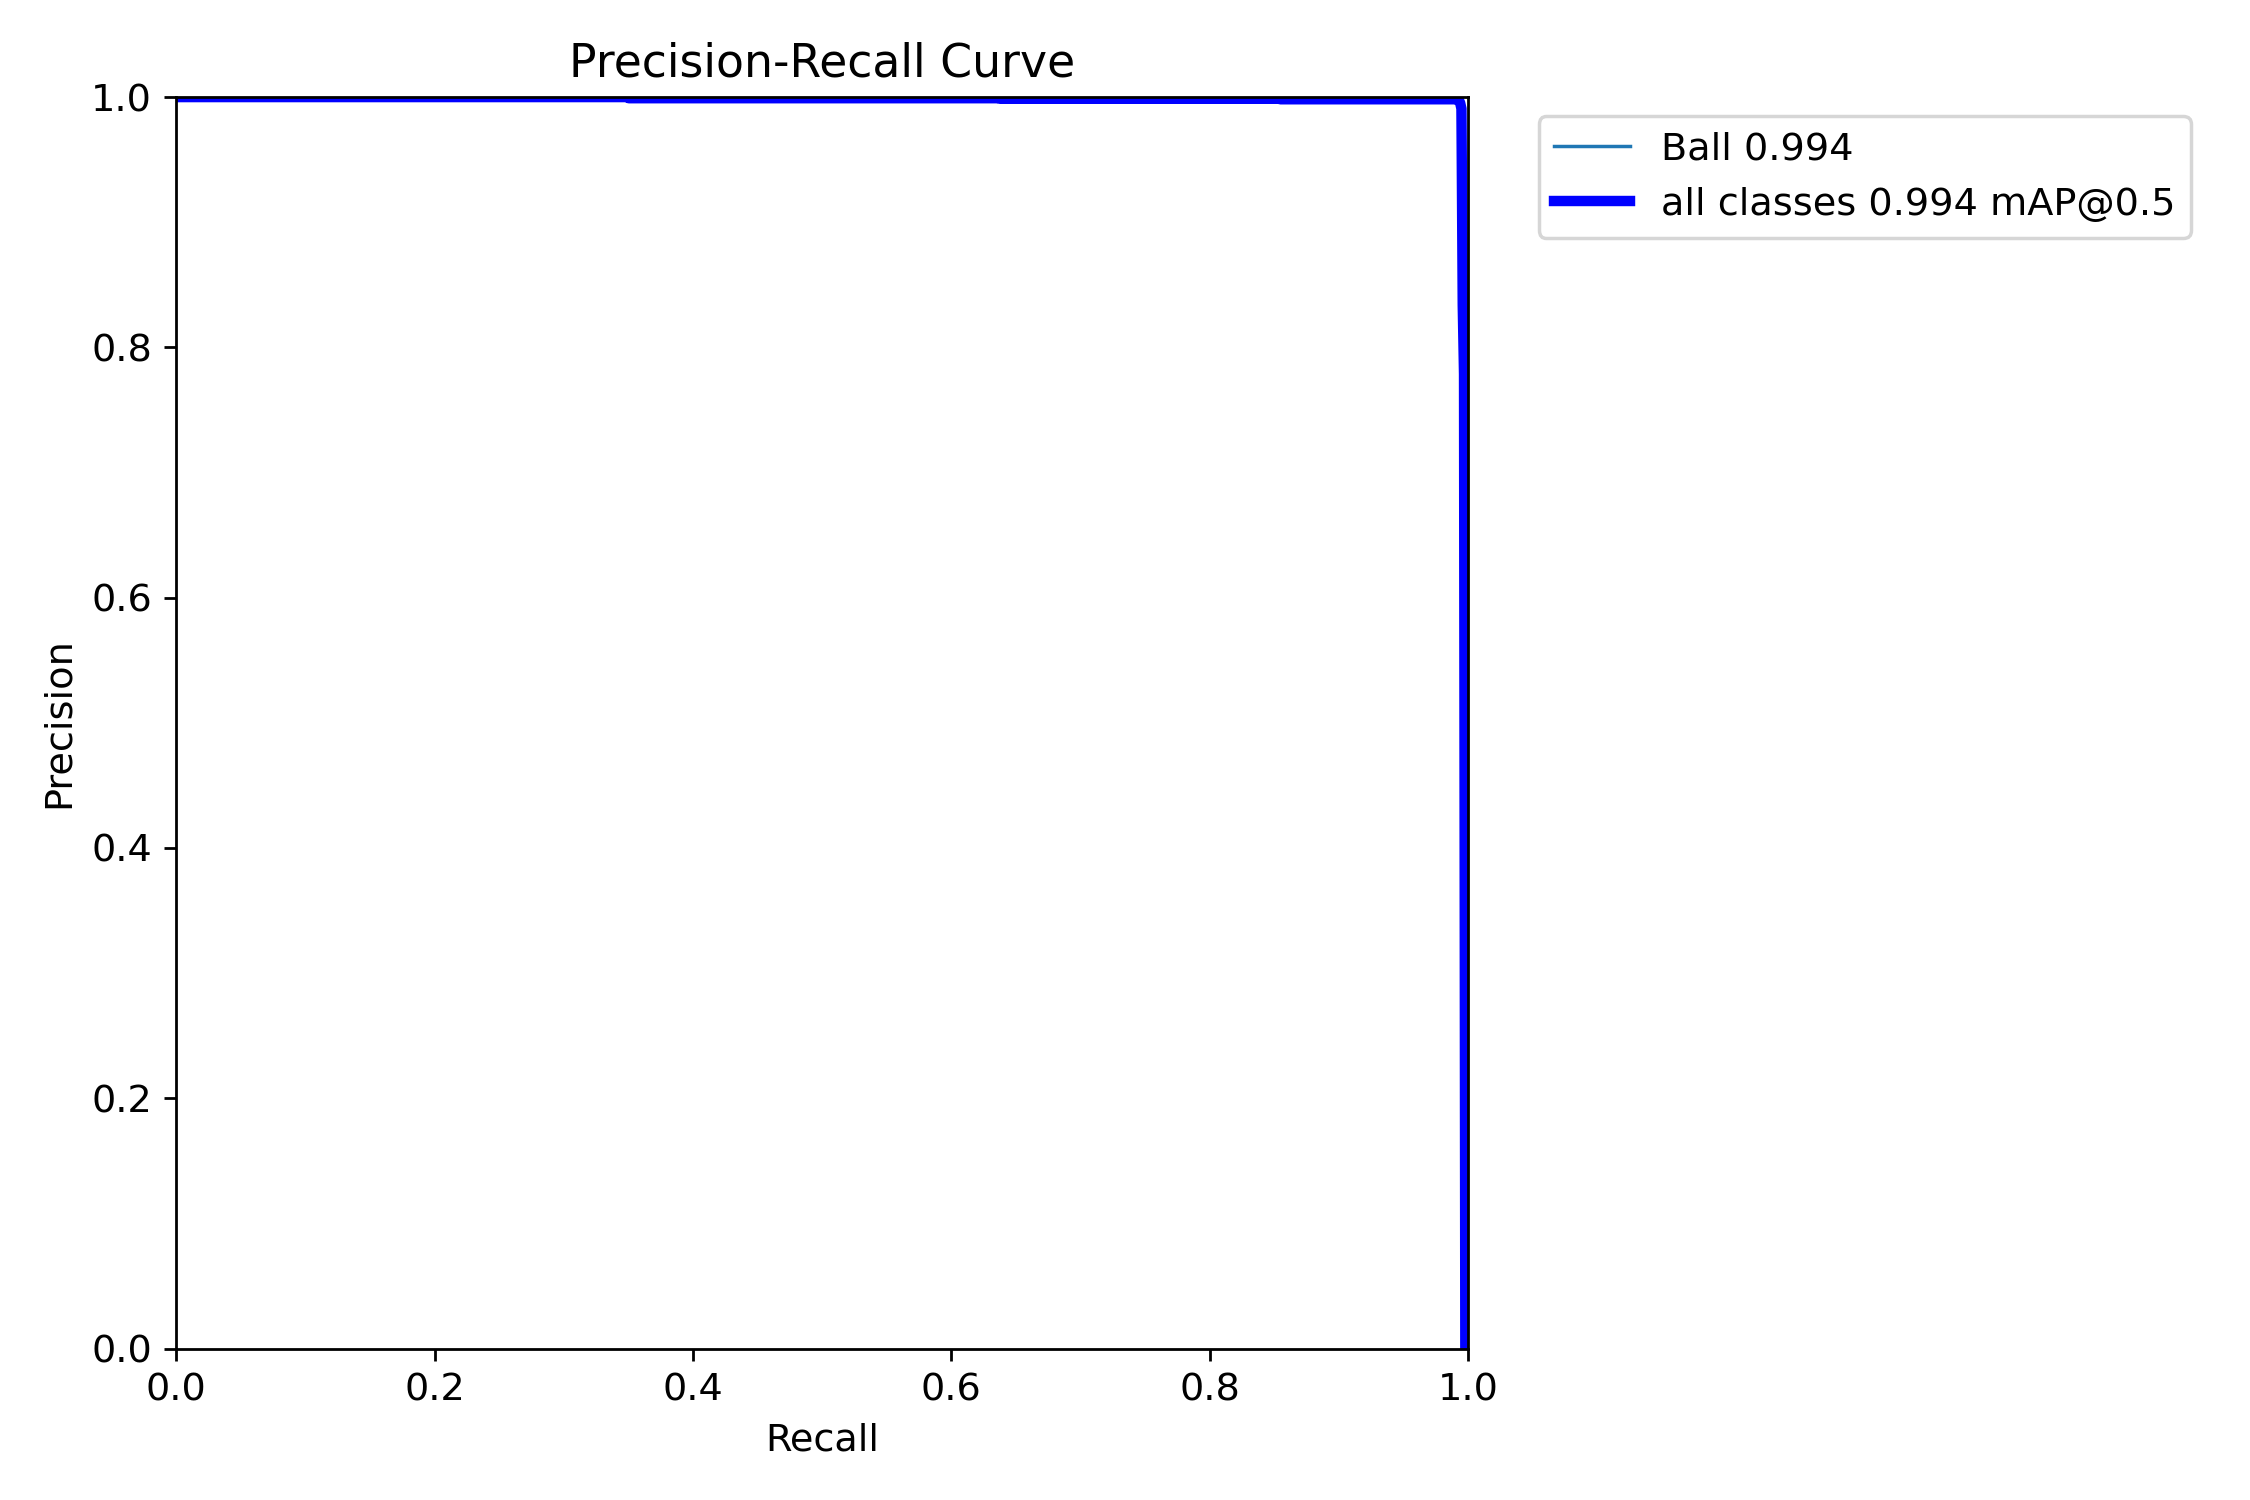

RT-DETR - Precision-Recall curve:


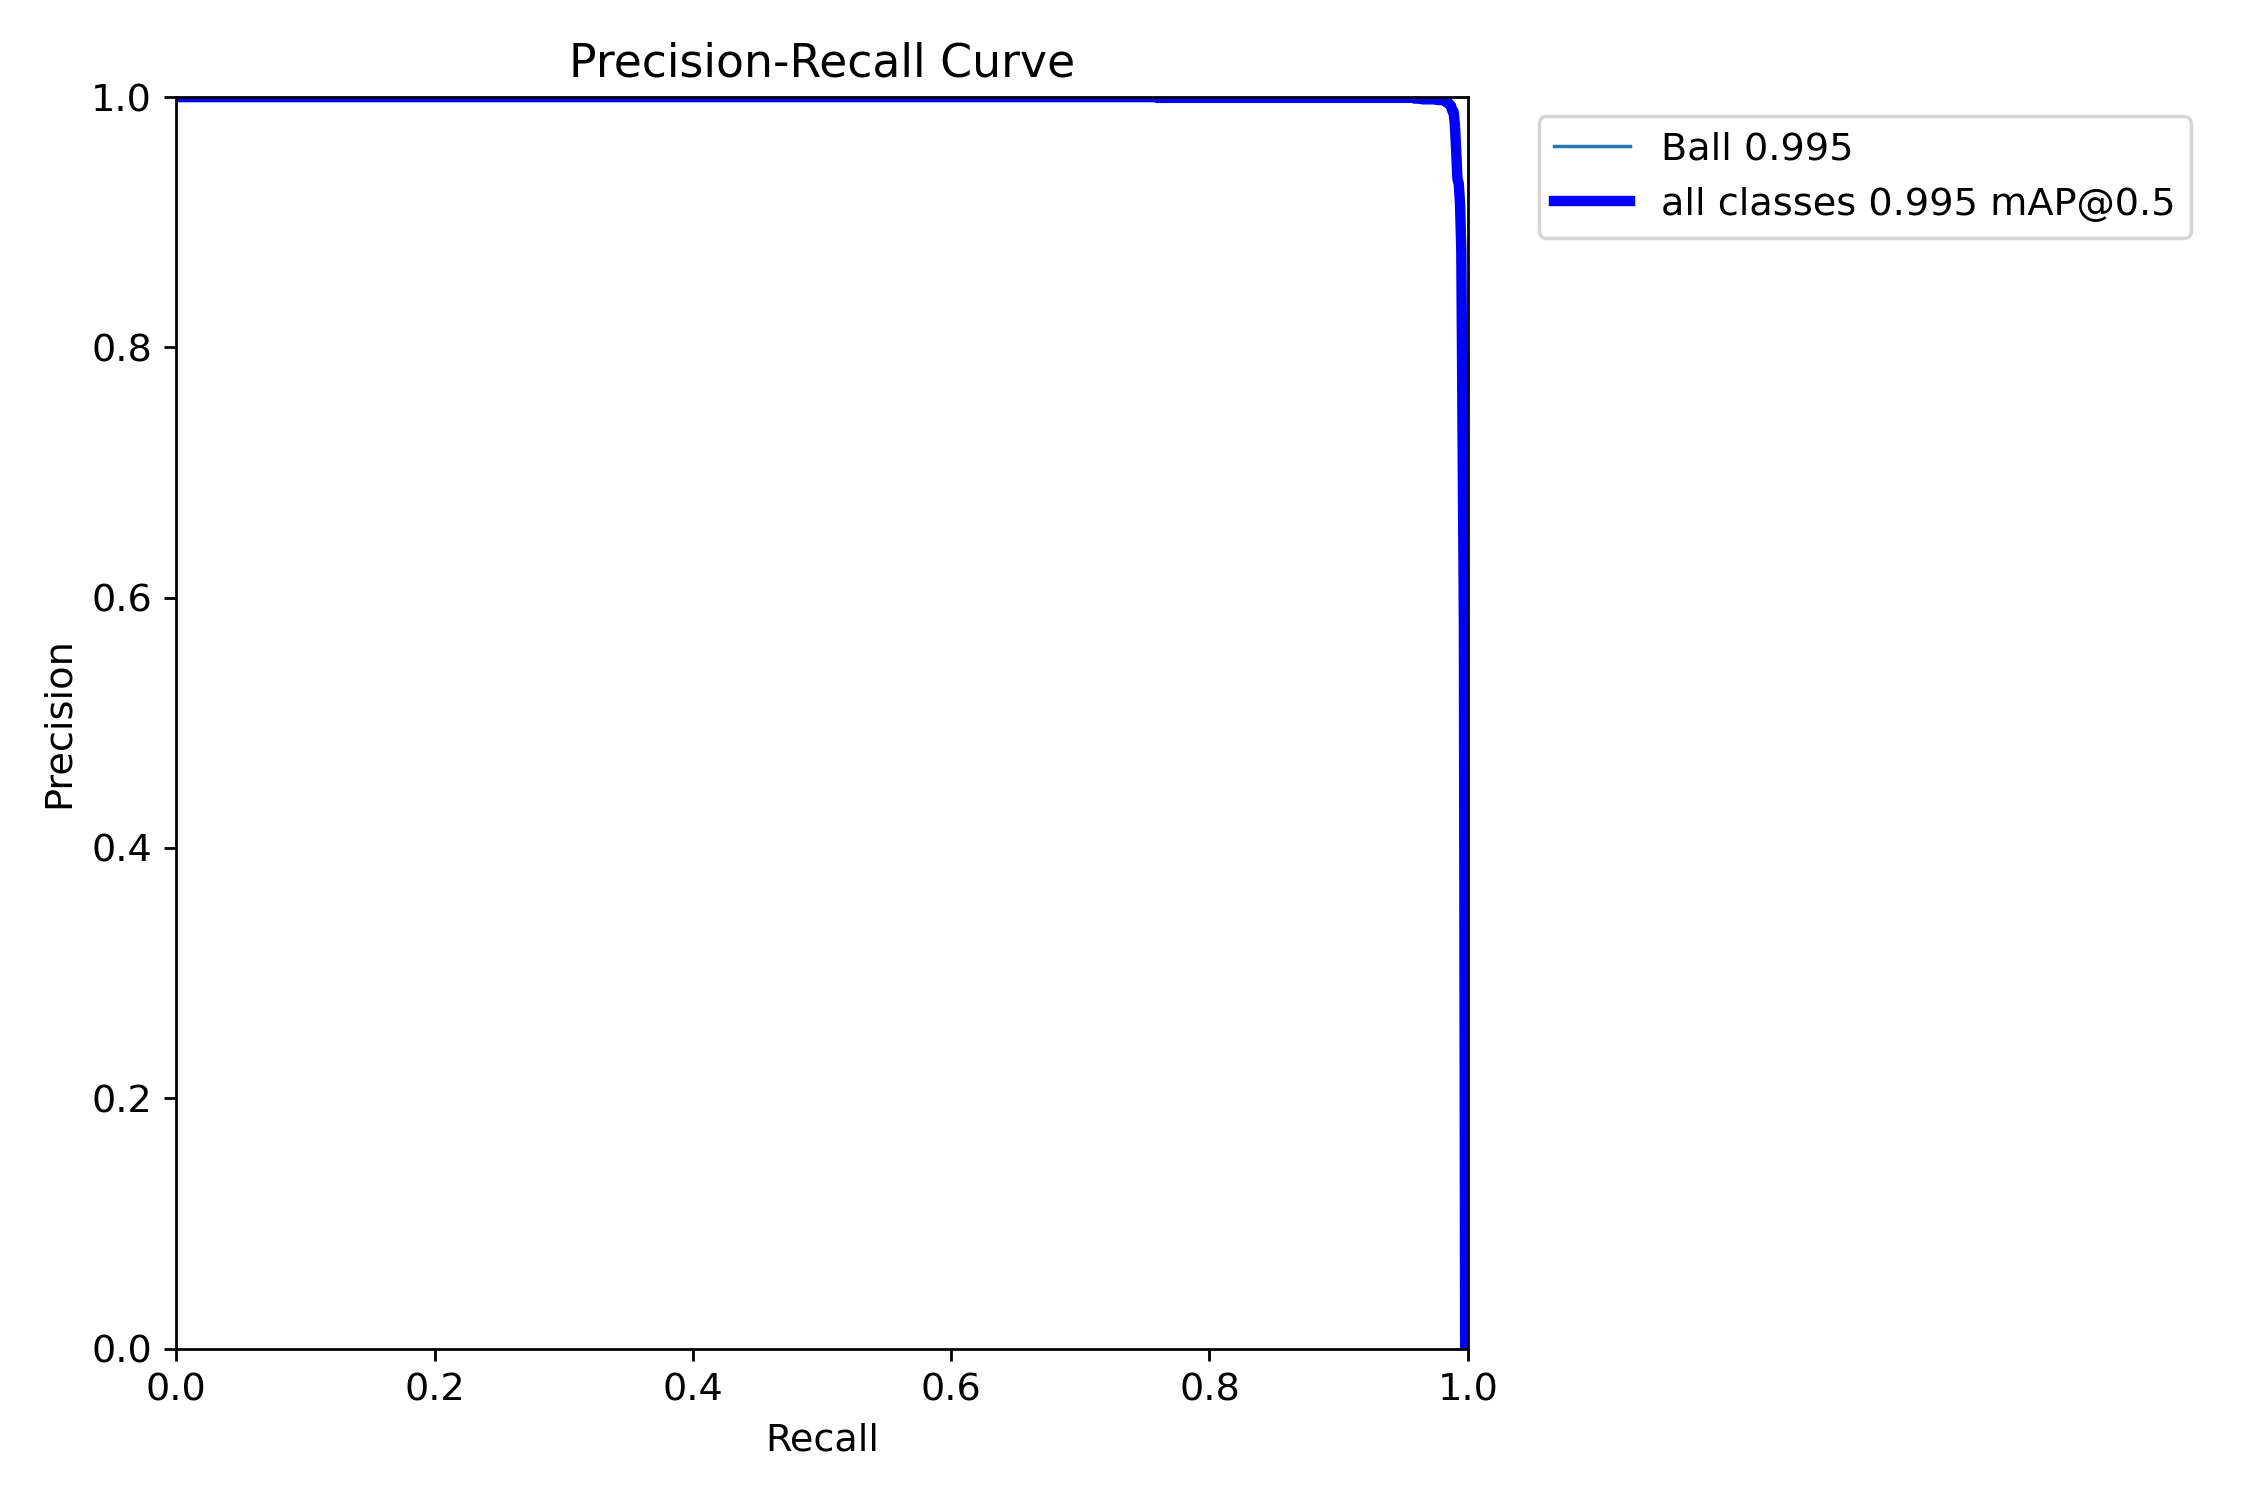

In [12]:
from IPython.display import Image as IPyImage, display

def show_artifact(run_dir, candidates, caption, width=480):
    # Display the first existing file among `candidates` inside run_dir.
    for name in candidates:
        path = os.path.join(run_dir, name)
        if os.path.exists(path):
            print(caption)
            display(IPyImage(filename=path, width=width))
            return
    print("(not found:", caption, "in", run_dir, ")")

for run_dir, title in [(YOLO_TEST_DIR, "YOLO11"), (RTDETR_TEST_DIR, "RT-DETR")]:
    show_artifact(run_dir, ["BoxPR_curve.png", "PR_curve.png"], f"{title} - Precision-Recall curve:")

**Training curves** (losses and mAP per epoch, from each model's training
run) and **confusion matrices** (on the test set). The training curves show
convergence and where early stopping kicked in.

YOLO11 - training curves:


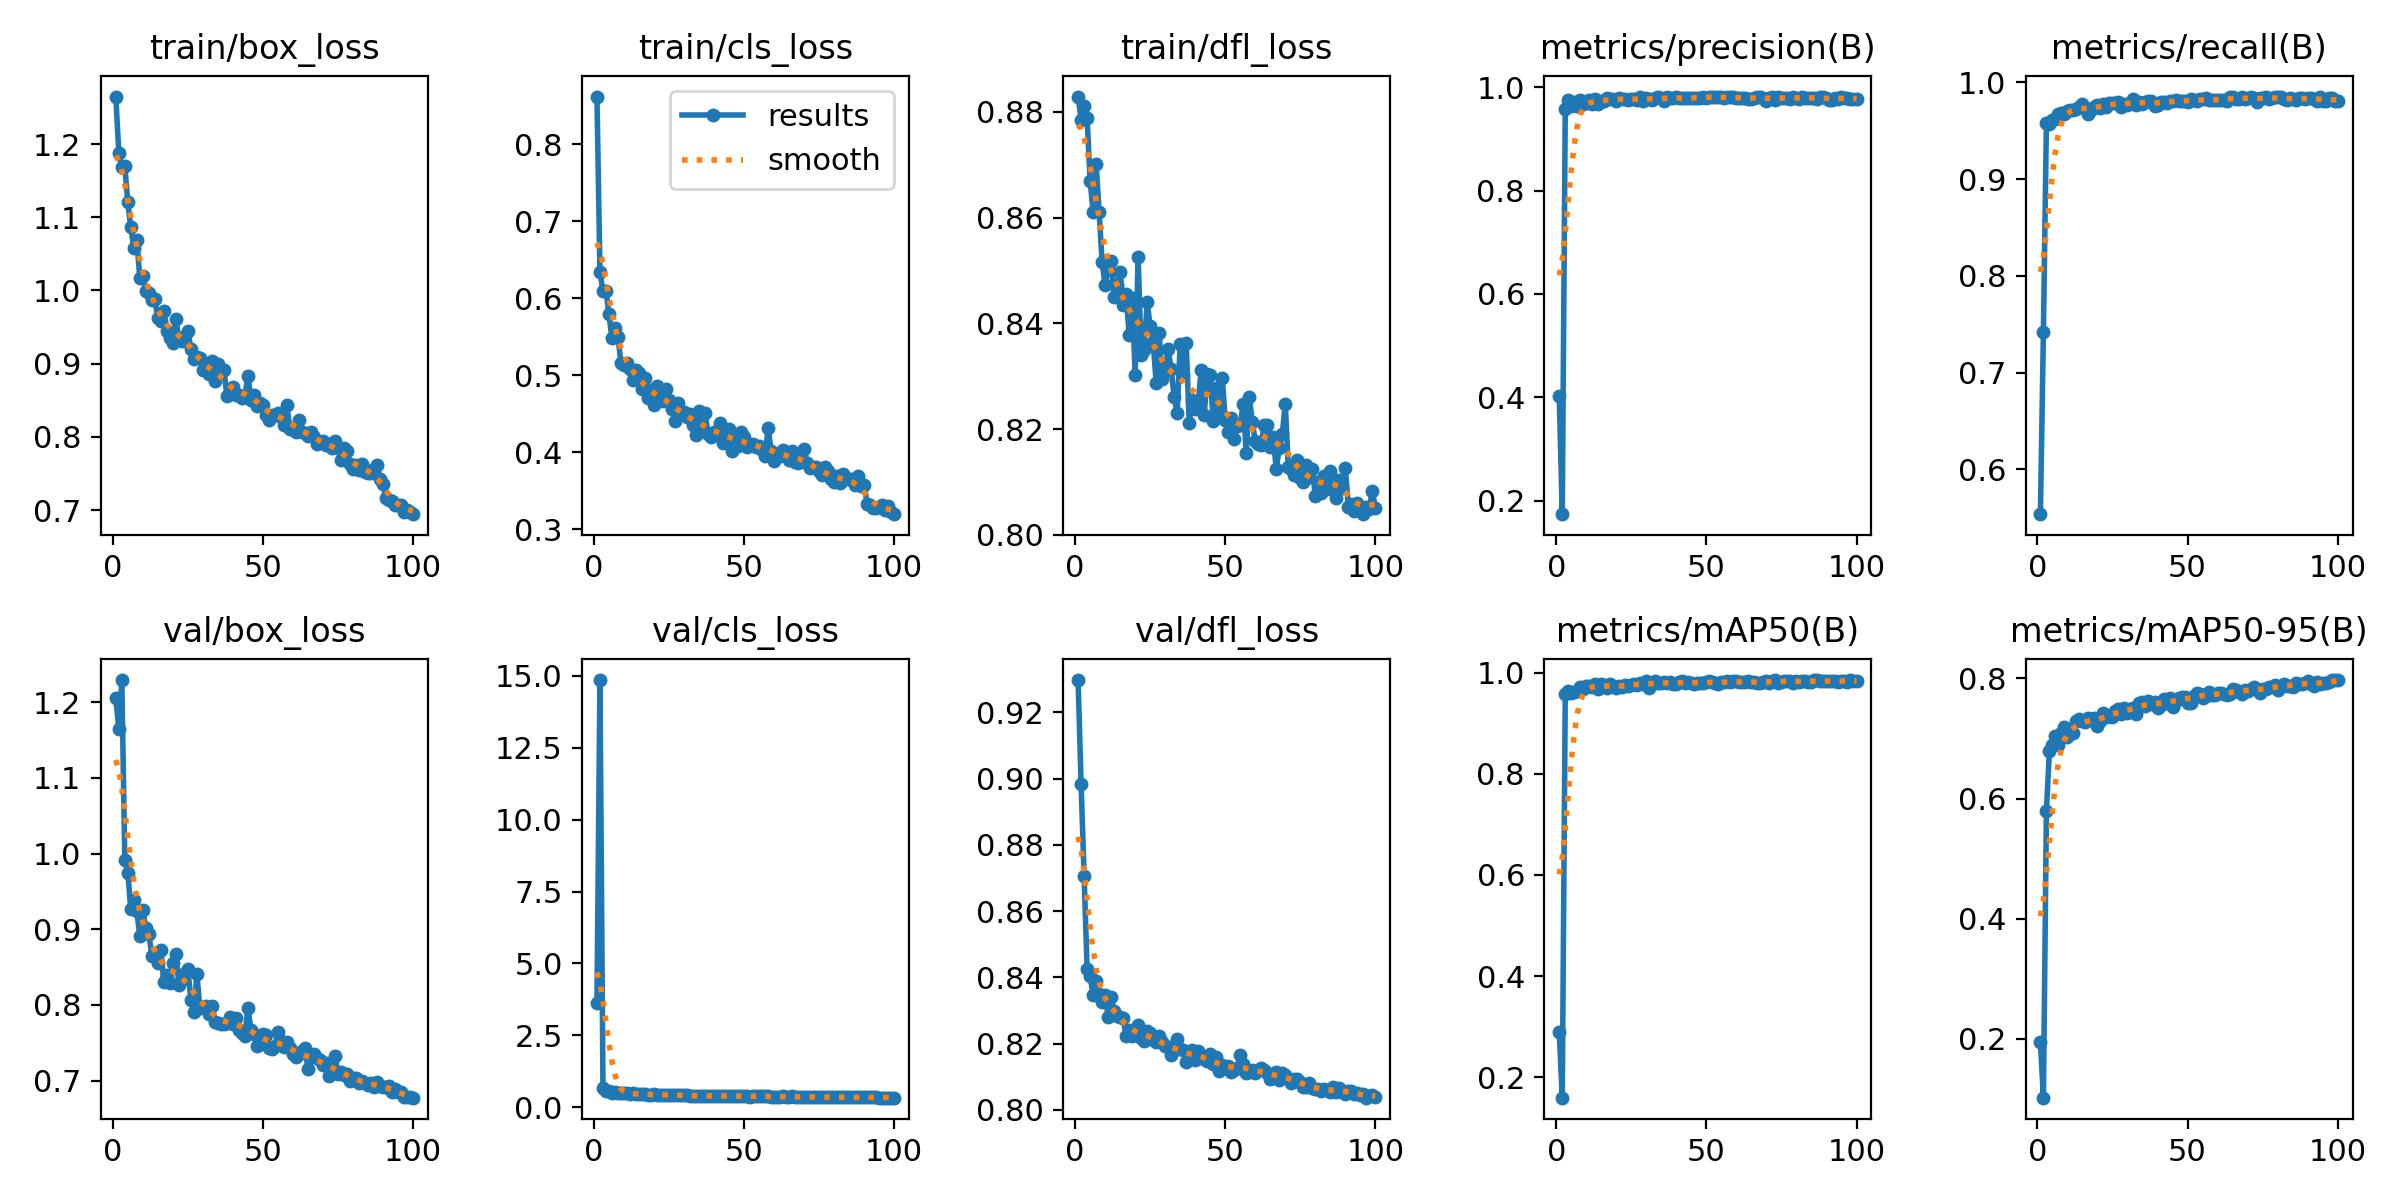

RT-DETR - training curves:


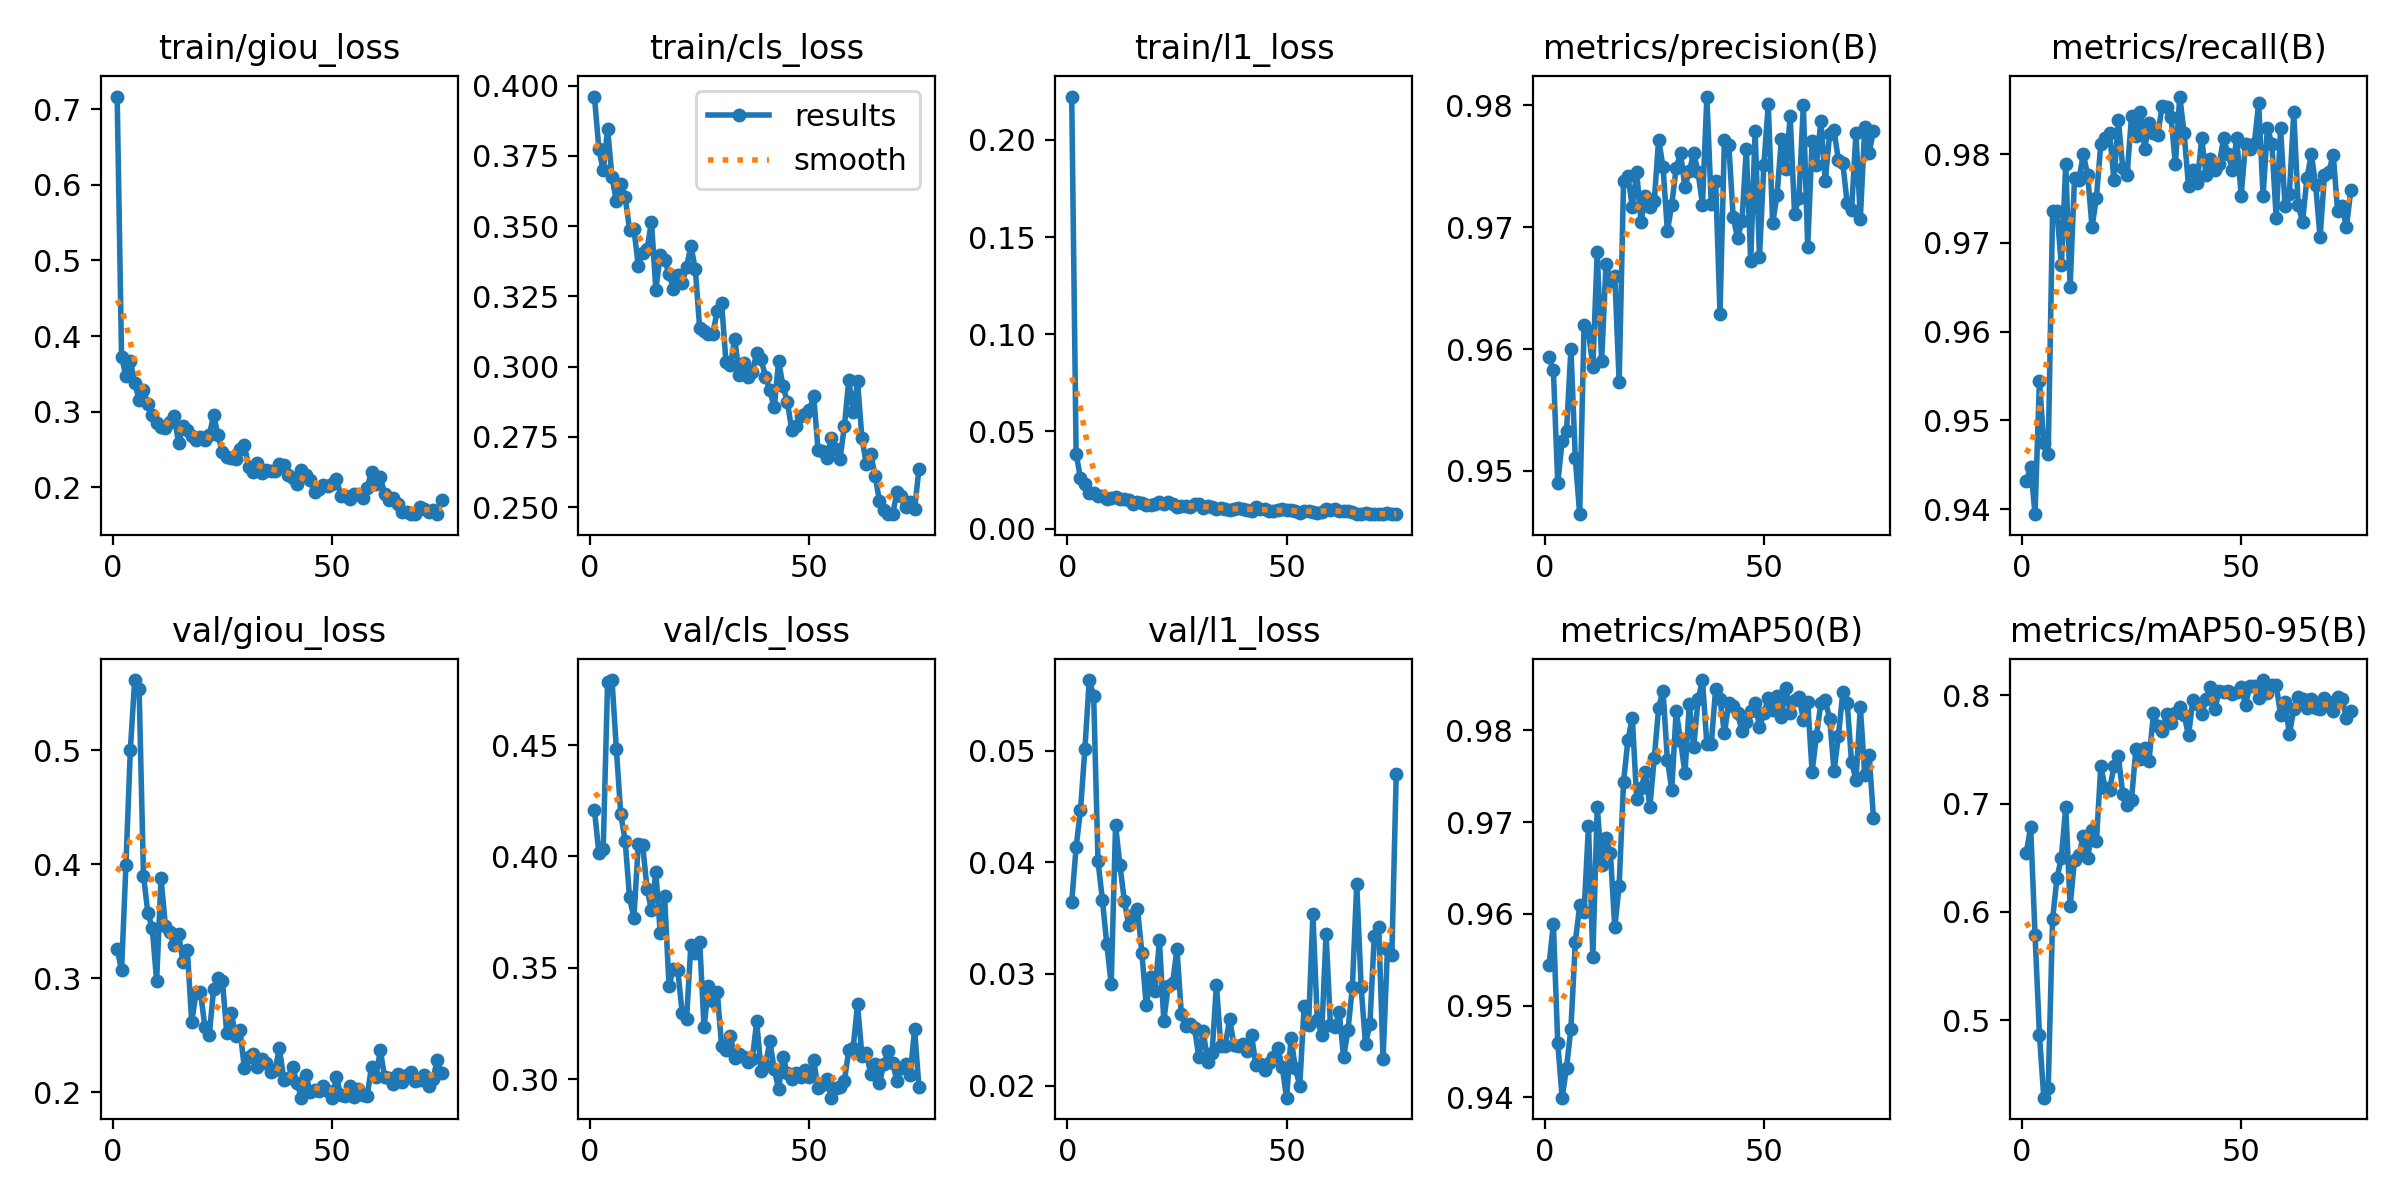

YOLO11 - confusion matrix (test):


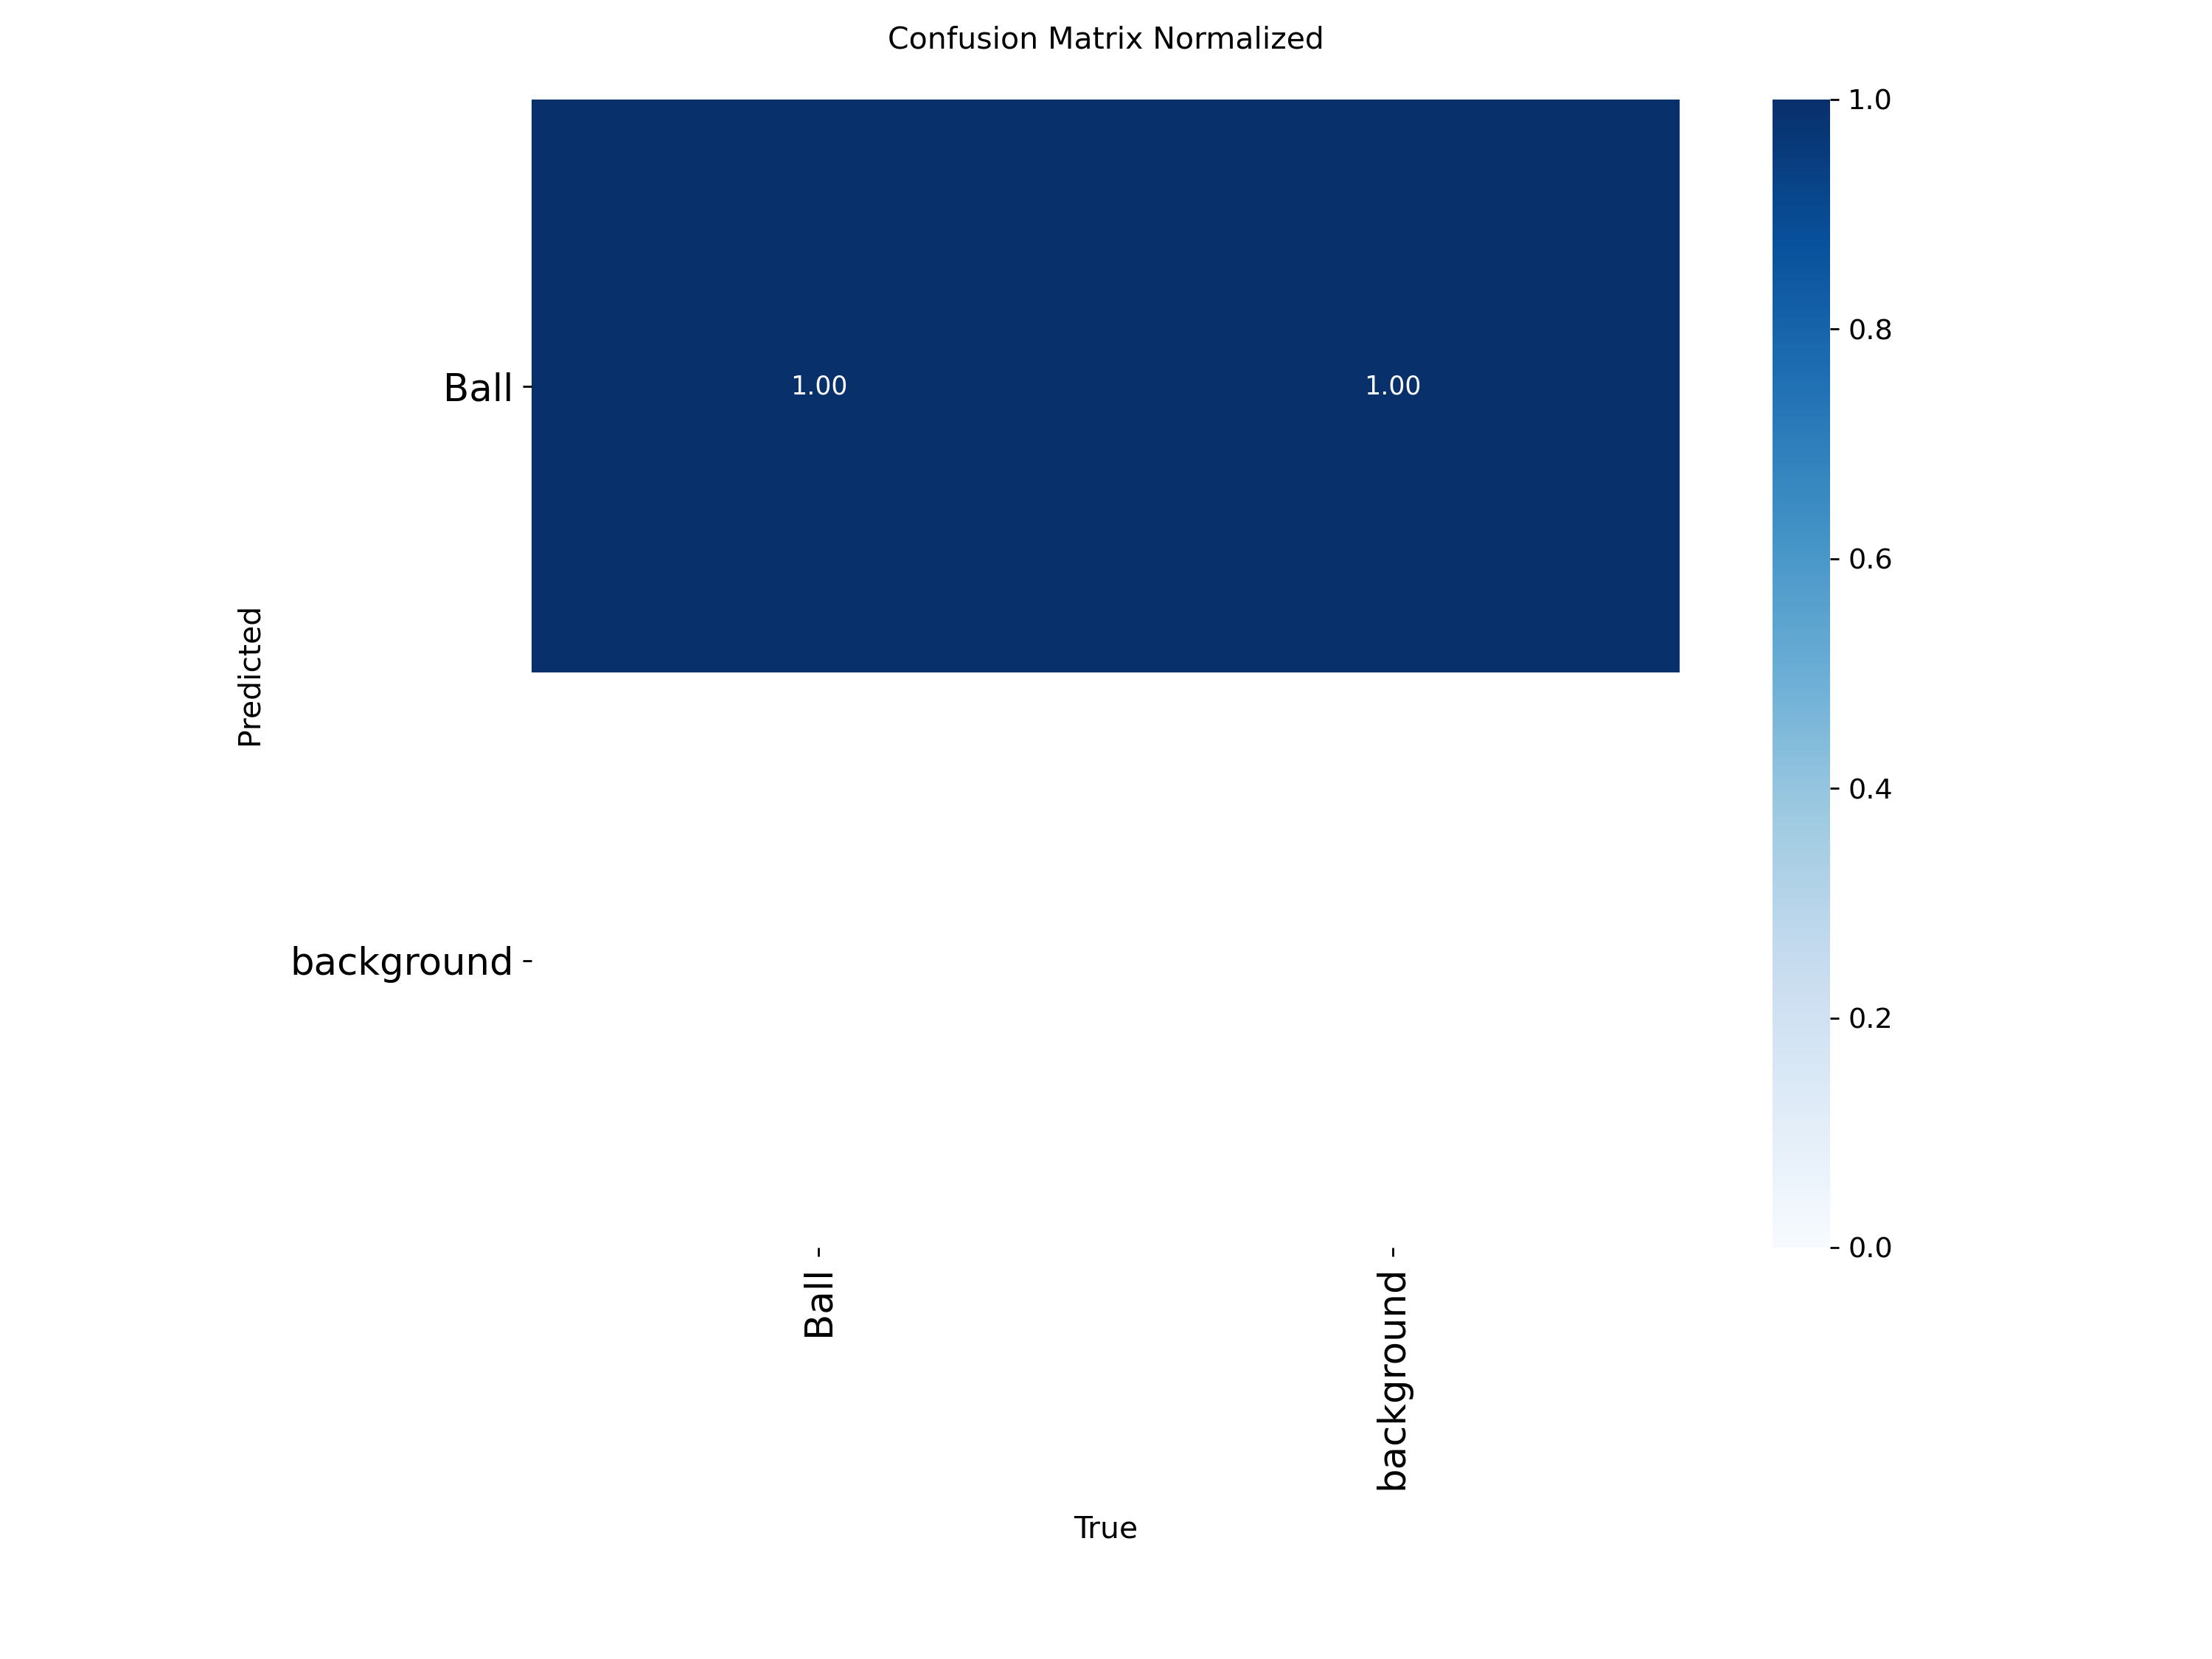

RT-DETR - confusion matrix (test):


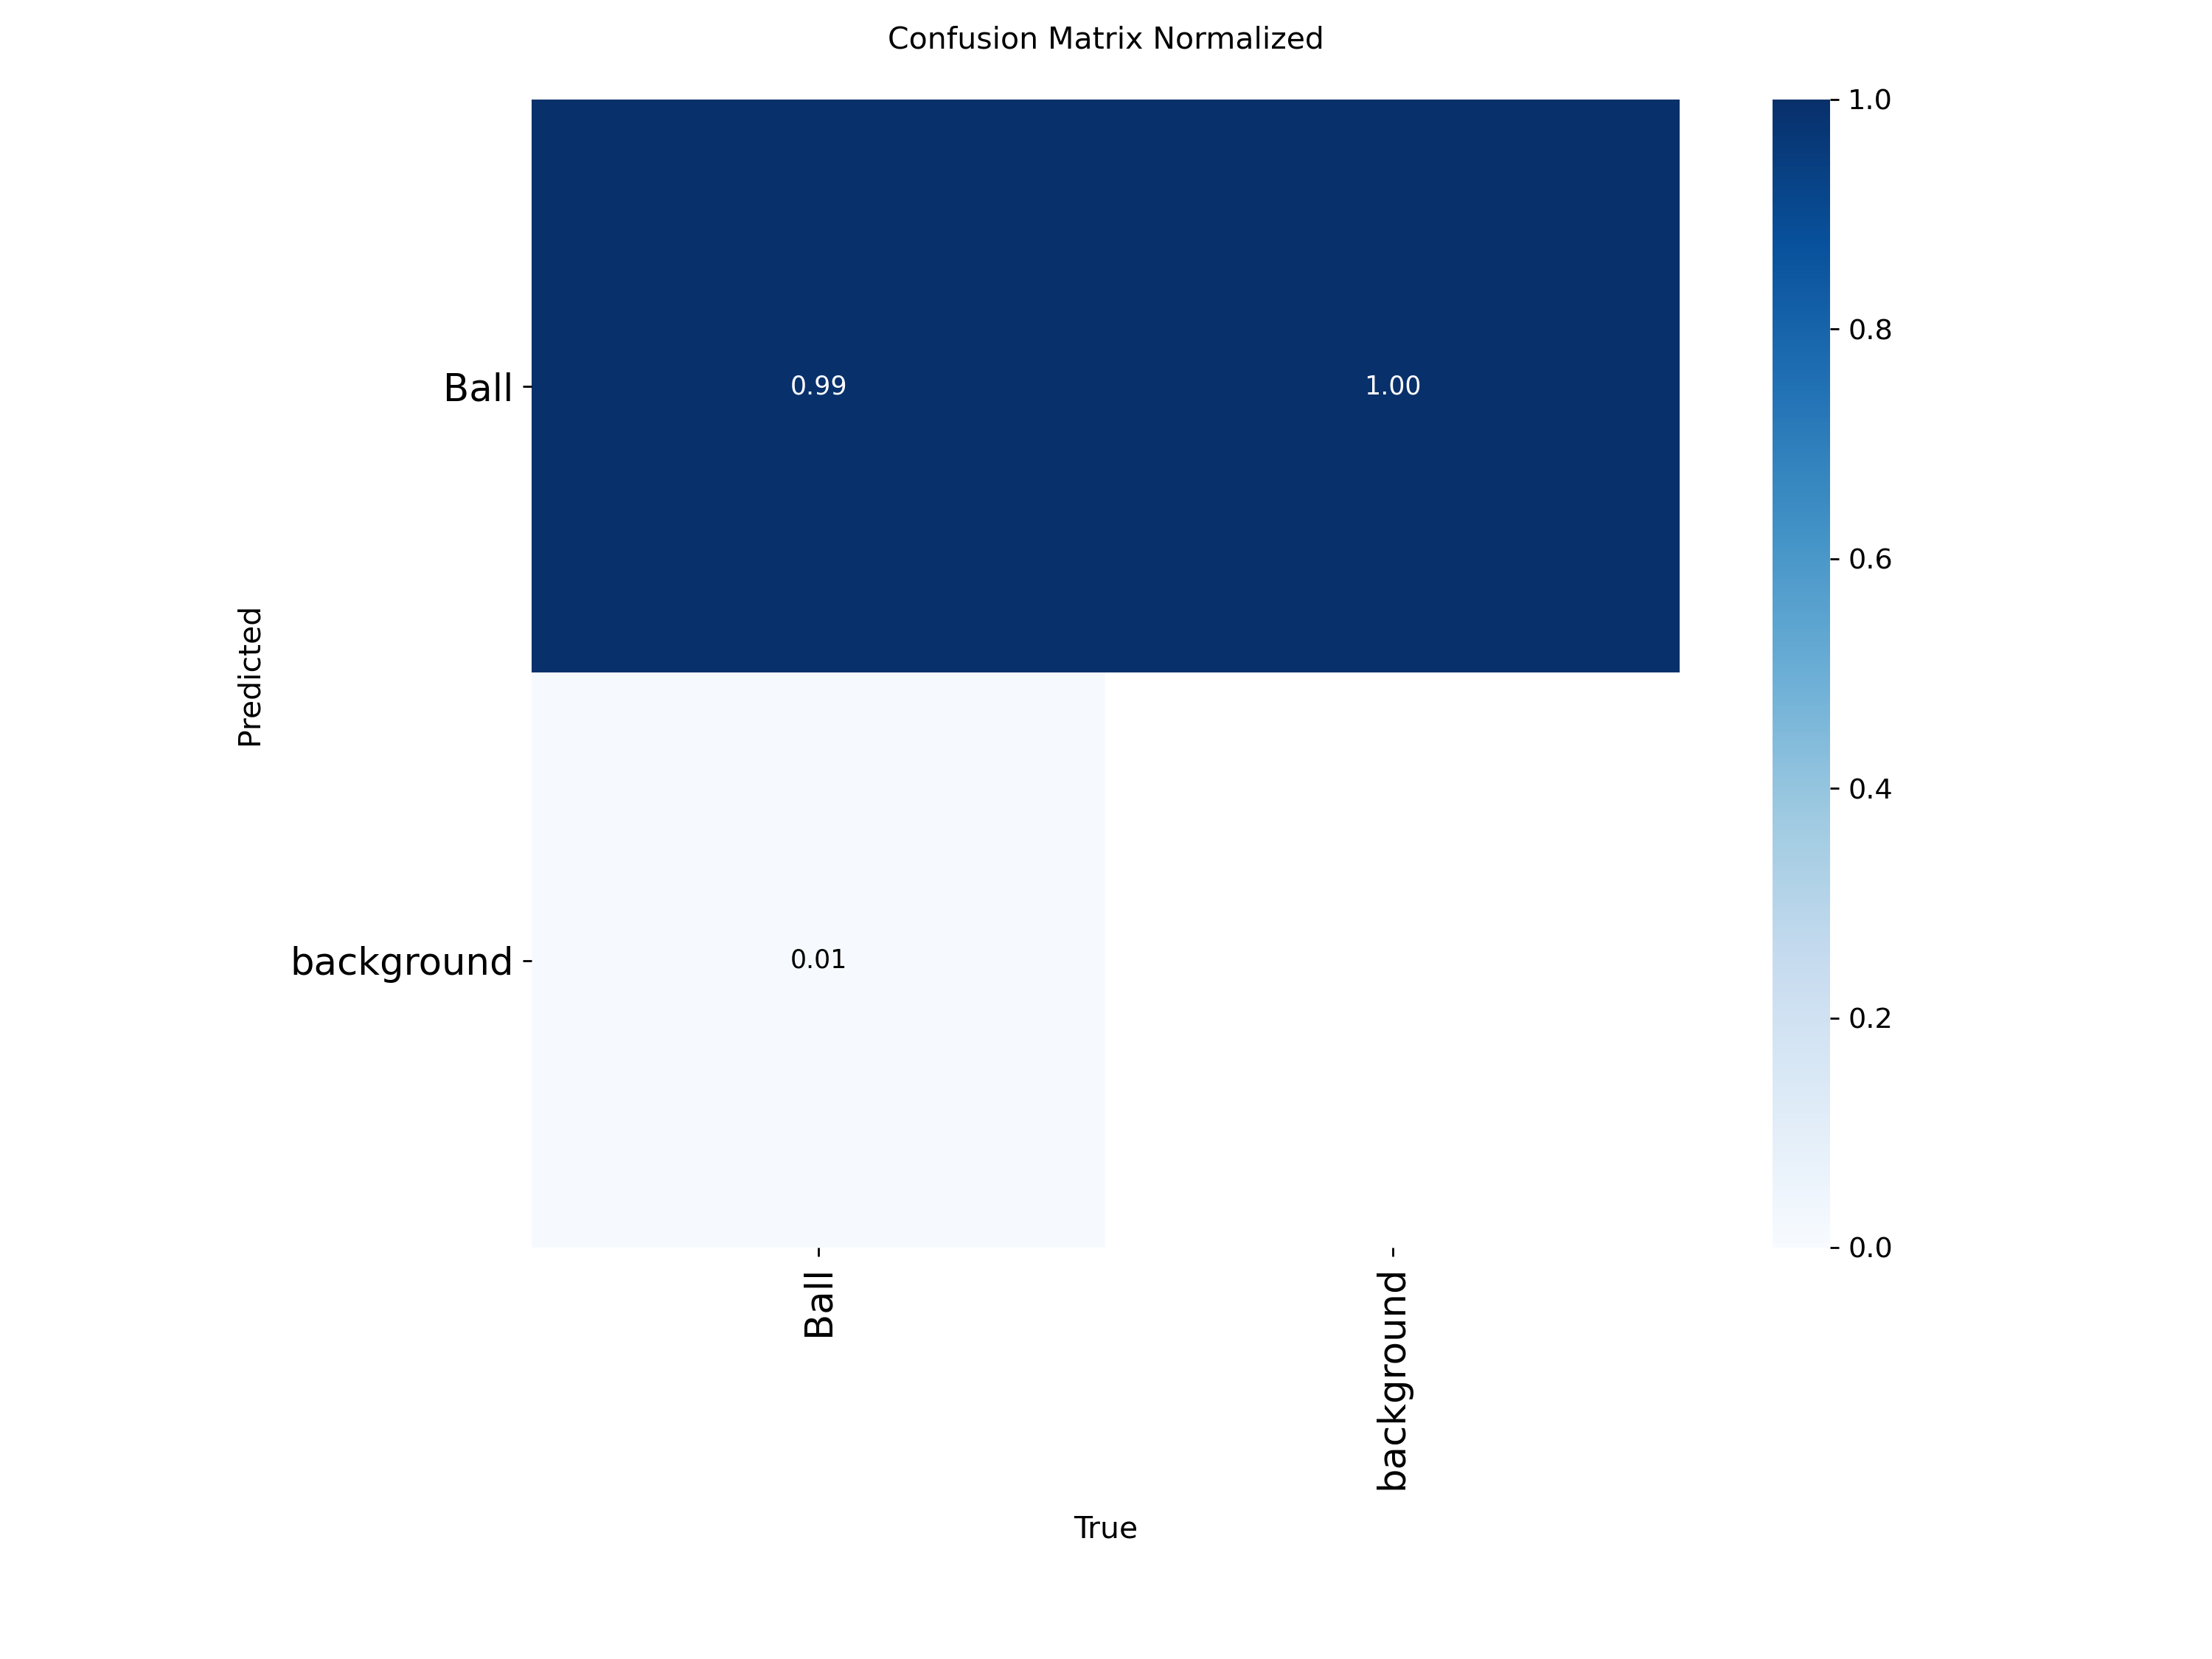

In [13]:
# Training curves: results.png lives in the TRAINING run dir.
for run_dir, title in [(YOLO_RUN, "YOLO11"), (RTDETR_RUN, "RT-DETR")]:
    show_artifact(run_dir, ["results.png"], f"{title} - training curves:", width=820)

# Confusion matrices: from the TEST evaluation dir (more meaningful than the val one).
for run_dir, title in [(YOLO_TEST_DIR, "YOLO11"), (RTDETR_TEST_DIR, "RT-DETR")]:
    show_artifact(run_dir, ["confusion_matrix_normalized.png", "confusion_matrix.png"],
                  f"{title} - confusion matrix (test):", width=480)

## 7. Qualitative results (good and bad cases)

We run both detectors over every test image and use the **gap between the number
of predicted boxes and the number of ground-truth boxes** as a cheap proxy to
*automatically* pick easy (good) and hard (bad) examples to show. For each chosen
image we display **GT | YOLO | RT-DETR** side by side.

In [14]:
CONF = 0.25  # confidence threshold for visualisation

# Reload both best models from their weights so this section is self-contained
# (robust even if earlier model objects were freed to save memory).
yolo_best = YOLO(os.path.join(YOLO_RUN, "weights", "best.pt"))
rtdetr_best = RTDETR(os.path.join(RTDETR_RUN, "weights", "best.pt"))

img_dir, lbl_dir = split_dir("test")
test_imgs = sorted(glob.glob(os.path.join(img_dir, "*.*")))

def n_gt(p):
    return count_boxes(os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + ".txt"))

# total predicted-vs-GT discrepancy per image (summed over both models)
rows = []
for p in test_imgs:
    g = n_gt(p)
    ny = len(yolo_best.predict(p, conf=CONF, imgsz=IMG_SIZE, device=DEVICE, verbose=False)[0].boxes)
    nr = len(rtdetr_best.predict(p, conf=CONF, imgsz=IMG_SIZE, device=DEVICE, verbose=False)[0].boxes)
    rows.append({"path": p, "gt": g, "yolo": ny, "rtdetr": nr, "err": abs(ny - g) + abs(nr - g)})

df = pd.DataFrame(rows).sort_values("err")
good = df.head(3)["path"].tolist()   # smallest discrepancy
bad  = df.tail(3)["path"].tolist()   # largest discrepancy
print("Good (low error):"); print(df.head(3)[["path", "gt", "yolo", "rtdetr"]].to_string(index=False))
print("\nBad (high error):"); print(df.tail(3)[["path", "gt", "yolo", "rtdetr"]].to_string(index=False))

Good (low error):
                                                                                        path  gt  yolo  rtdetr
dataset/test/images/122_sct-mon1_170x250_850x560_png.rf.0d95fadf0ce1cabf97d96ed059460c90.jpg   6     6       6
                         dataset/test/images/119_png.rf.eff91a09289a82f634d7b231b06dbbdd.jpg   9     9       9
                       dataset/test/images/13147_png.rf.3bc88cdb7e99a780d4a4b94e2f49857b.jpg  16    16      16

Bad (high error):
                                                                               path  gt  yolo  rtdetr
dataset/test/images/IMG_20240319_121500_jpg.rf.47ddaaeafe6c2898a73342fc3f5076a3.jpg  16    17      22
              dataset/test/images/13263_png.rf.2f6ecf36c207a101aeec92673f25c149.jpg  16    16      29
              dataset/test/images/13172_png.rf.08f3f9f6717cb384d85a47a3b2acb959.jpg  16    16      45


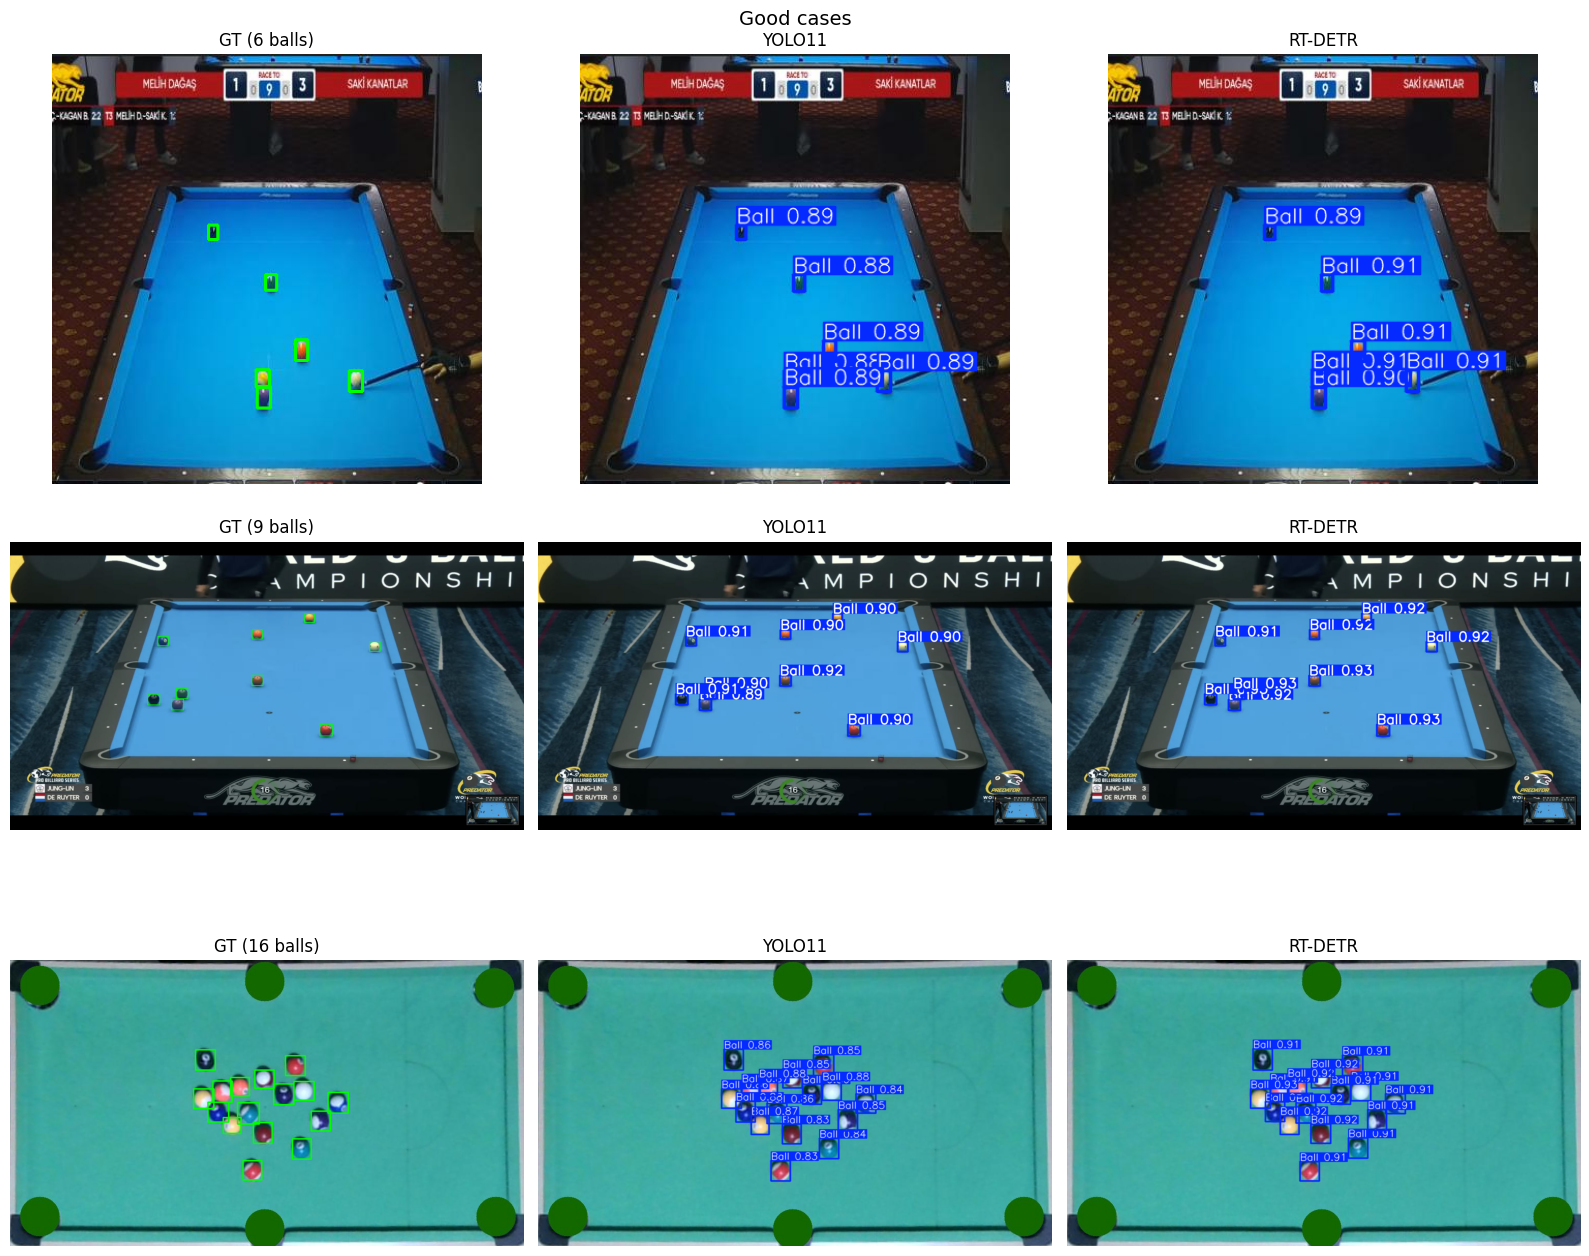

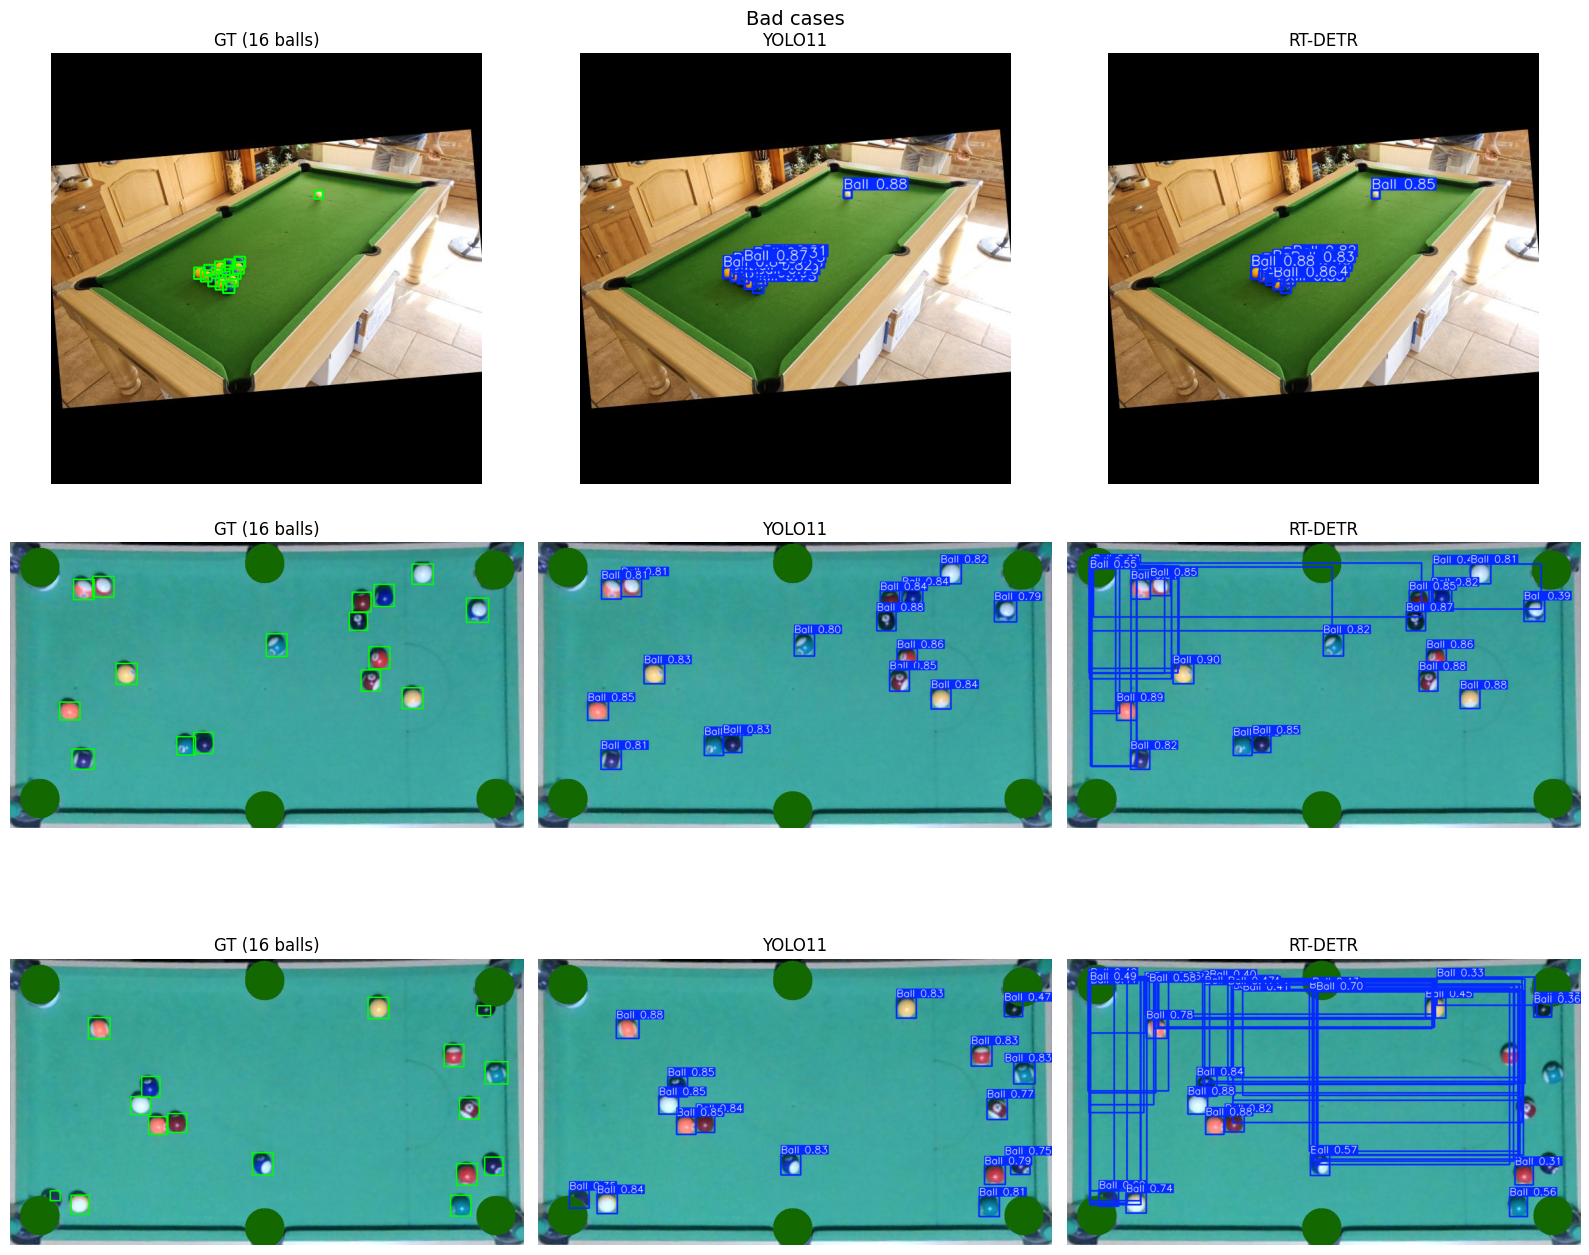

In [15]:
def pred_rgb(model, img_path):
    res = model.predict(img_path, conf=CONF, imgsz=IMG_SIZE, device=DEVICE, verbose=False)[0]
    return cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

def show_triplets(paths, banner):
    fig, axes = plt.subplots(len(paths), 3, figsize=(16, 4.5 * len(paths)))
    axes = np.atleast_2d(axes)
    for r, p in enumerate(paths):
        lbl = os.path.join(lbl_dir, os.path.splitext(os.path.basename(p))[0] + ".txt")
        axes[r][0].imshow(draw_gt(p, lbl));      axes[r][0].set_title(f"GT ({n_gt(p)} balls)")
        axes[r][1].imshow(pred_rgb(yolo_best, p)); axes[r][1].set_title("YOLO11")
        axes[r][2].imshow(pred_rgb(rtdetr_best, p)); axes[r][2].set_title("RT-DETR")
        for c in range(3):
            axes[r][c].axis("off")
    fig.suptitle(banner, fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, banner.lower().replace(" ", "_") + ".png"), dpi=120)
    plt.show()

show_triplets(good, "Good cases")
show_triplets(bad,  "Bad cases")

## 8. Conclusions / notes for the report

Fill these in from the numbers above:

- **Which model wins on accuracy** (mAP@0.5:0.95) and by how much.
- **Cost trade-off:** params and ms/image — is the more accurate model also slower/heavier?
- **Failure modes** seen in the *bad cases* (e.g. occluded/clustered balls, balls near
  the cushions, balls confused with reflections or pocket markers, the white cue ball).
- **Small-object angle:** did the larger `IMG_SIZE` help? Worth mentioning that
  YOLO26's small-target label assignment targets exactly this.

**Things to acknowledge (required):** `ultralytics` (YOLO11 + RT-DETR), the pretrained
COCO weights used for transfer learning, and any AI tools used while developing the code.

**Possible extras to push the grade higher:**
- Add a third model (e.g. `yolo26s`) for a 3-way comparison.
- Feed the detected ball positions into the *retrieval* part of Task 3 (represent each
  table by its set of ball centroids) — this links the two halves of the task.
- Train the canonical `facebook/detr-resnet-50` via HuggingFace for a "textbook DETR"
  data point (needs a YOLO->COCO label conversion and more epochs to converge).
